---

# AXIS LIMITS

---

>---
>the `set_ylim()` and `set_xlim()` functions let you modify the **axis limits**
>
```python
    ax.set_xlim(lower limit, upper limit)

```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

In [2]:
df = pd.read_csv('../Data/ca_housing.csv', parse_dates=['period_begin', 'period_end'])

df = (df
    .pivot_table(index='period_begin', 
                 columns='region_name', 
                 values='median_active_list_price', 
                 aggfunc='mean')
    .assign(CA_Average = lambda x: x.mean(axis=1))
    .resample('QE').mean().round()
     )

display(df)
df.info()

region_name,Los Angeles,San Diego,San Francisco,CA_Average
period_begin,,,,
2017-03-31,630557.0,637701.0,1263499.0,843919.0
2017-06-30,650077.0,652195.0,1259083.0,853785.0
2017-09-30,651898.0,646279.0,1276378.0,858185.0
2017-12-31,655576.0,645082.0,1300292.0,866983.0
2018-03-31,686360.0,660420.0,1333339.0,893373.0
2018-06-30,698958.0,672297.0,1366697.0,912651.0
2018-09-30,694917.0,651794.0,1362654.0,903122.0
2018-12-31,685525.0,649886.0,1370784.0,902065.0
2019-03-31,709834.0,673348.0,1434700.0,939294.0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22 entries, 2017-03-31 to 2022-06-30
Freq: QE-DEC
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Los Angeles    22 non-null     float64
 1   San Diego      22 non-null     float64
 2   San Francisco  22 non-null     float64
 3   CA_Average     22 non-null     float64
dtypes: float64(4)
memory usage: 880.0 bytes


<br><br>

---

In [3]:
a = pd.to_datetime('1970-01-01')
b = pd.to_datetime('2017-03-01')
result1 = (b - a).days
print(f'Lower Limit: {result1}')

c = pd.to_datetime('1970-01-01')
d = pd.to_datetime('2022-07-31')
result2 = (d - c).days
print(f'Upper Limit: {result2}')

Lower Limit: 17226
Upper Limit: 19204


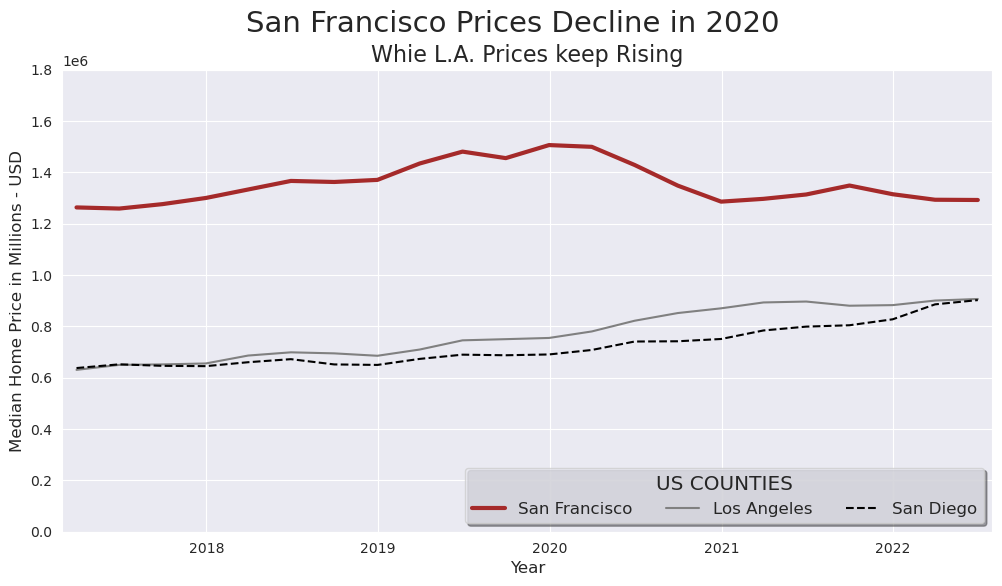

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df['San Francisco'], label='San Francisco',
        color='brown', linestyle='-', linewidth=3)

ax.plot(df['Los Angeles'], label='Los Angeles',
        color='gray', linestyle='-', linewidth=1.5)

ax.plot(df['San Diego'], label='San Diego',
        color='black', linestyle='--', linewidth=1.5)

fig.suptitle('San Francisco Prices Decline in 2020', fontsize=21)
ax.set_title('Whie L.A. Prices keep Rising', fontsize=16)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Median Home Price in Millions - USD', fontsize=12)
ax.legend(loc='lower right',
          ncols=3,
          fancybox=True,
          shadow=True,
          framealpha=0.75,
          title='US COUNTIES',
          title_fontsize='x-large',
          fontsize='large'
         )

ax.set_xlim(17226, 19204) # (2017-03-01, 2022-07-31) number of days since 1970-01-01
ax.set_ylim(0, 1800000) # y-axis units
plt.show()

<br><br>

---

## LABORATORY

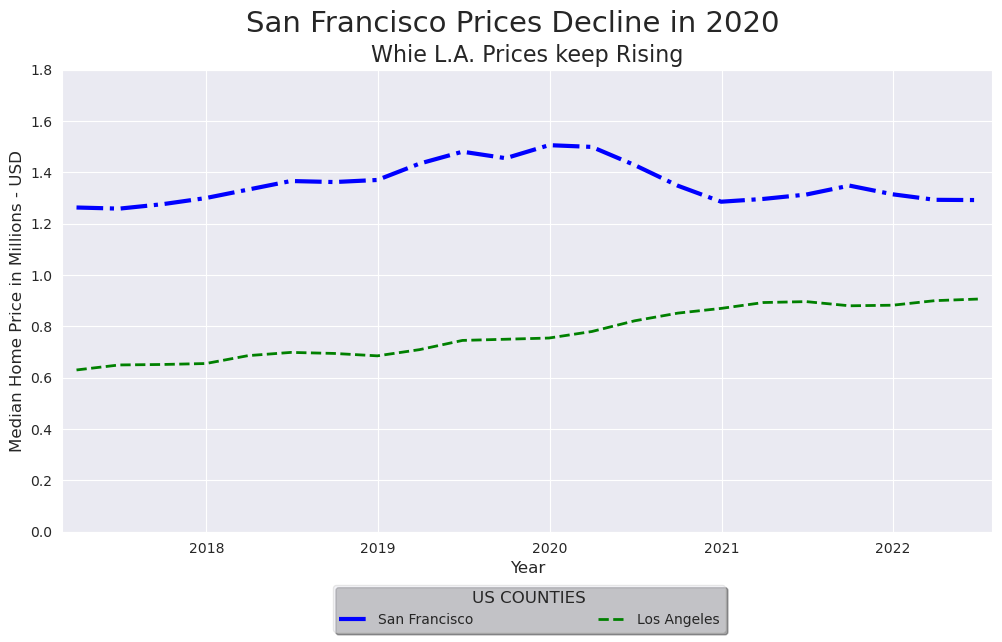

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df['San Francisco']/1e6, 
        label='San Francisco',
        color='blue', 
        linestyle='-.', 
        linewidth=3)

ax.plot(df['Los Angeles']/1e6, 
        label='Los Angeles',
        color='green', 
        linestyle='--', 
        linewidth=2)

fig.suptitle('San Francisco Prices Decline in 2020', fontsize=21)
ax.set_title('Whie L.A. Prices keep Rising', fontsize=16)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Median Home Price in Millions - USD', fontsize=12)
ax.legend(bbox_to_anchor=(0.72, -0.1),
          ncols=2,
          shadow=True,
          framealpha=0.45,
          title='US COUNTIES',
          title_fontsize='large',
          fontsize='medium',
          columnspacing=9
         )

ax.set_xlim(17226, 19204) # (2017-03-01, 2022-07-31) number of days since 1970-01-01
ax.set_ylim(0, 1.8) # y-axis units
plt.show()